 # 1. Cargar la imagen y convertirla a escala de grises

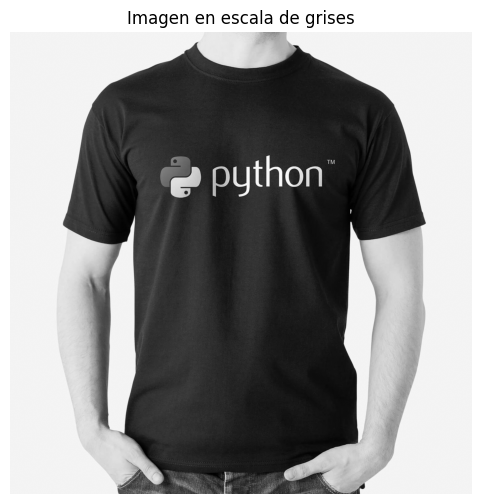

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from scipy.ndimage import convolve

# Cargar la imagen
image_path = "/content/Python_BLACK_Mockup.jpg"
image = io.imread(image_path)

# Convertir a escala de grises
gray_image = color.rgb2gray(image)

# Mostrar imagen original
plt.figure(figsize=(6,6))
plt.imshow(gray_image, cmap='gray')
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

# 2. Aplicar convolución con Stride

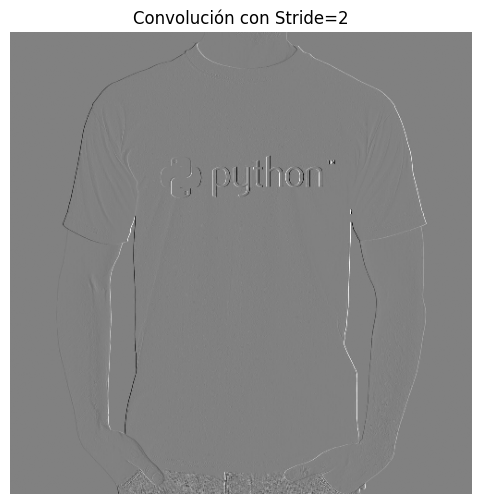

In [7]:
# Definir un kernel simple de detección de bordes (Sobel en x)
kernel = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]])

# Aplicar convolución
convolved_image = convolve(gray_image, kernel)

# Aplicar stride manualmente (salto de 2 píxeles)
stride = 3
convolved_stride = convolved_image[::stride, ::stride]

# Mostrar resultado
plt.figure(figsize=(6,6))
plt.imshow(convolved_stride, cmap='gray')
plt.title("Convolución con Stride=2")
plt.axis("off")
plt.show()


# 3. Aplicar Padding

In [13]:
!pip install --upgrade scikit-image

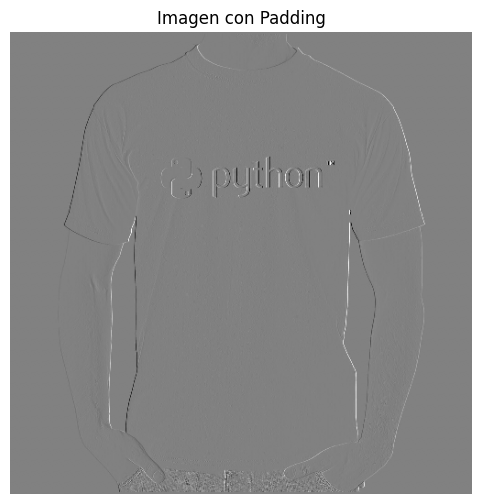

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Crear una imagen de ejemplo (matriz 100x100)
gray_image = np.ones((100, 100))

# Aplicar padding de 10 píxeles con numpy
padded_image = np.pad(convolved_stride, pad_width=2, mode="constant", constant_values=0)

# Mostrar resultado
plt.figure(figsize=(6,6))
plt.imshow(padded_image, cmap='gray')
plt.title("Imagen con Padding")
plt.axis("off")
plt.show()


# 4. Aplicar Max Pooling

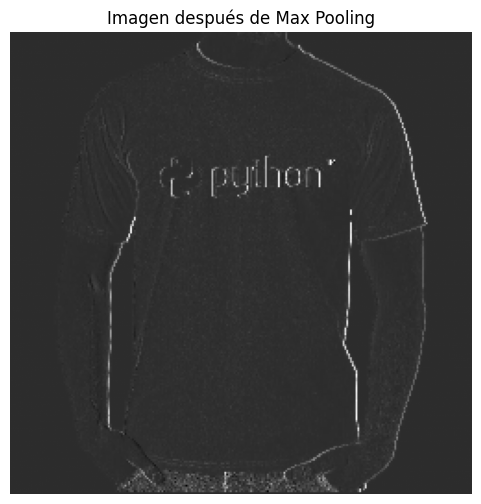

In [18]:
def max_pooling(image, pool_size=2):
    pooled_image = np.zeros((image.shape[0] // pool_size, image.shape[1] // pool_size))
    for i in range(0, image.shape[0] - pool_size, pool_size):
        for j in range(0, image.shape[1] - pool_size, pool_size):
            pooled_image[i // pool_size, j // pool_size] = np.max(image[i:i+pool_size, j:j+pool_size])
    return pooled_image

# Aplicar Max Pooling
pooled_image = max_pooling(convolved_stride, pool_size=2)

# Mostrar resultado
plt.figure(figsize=(6,6))
plt.imshow(pooled_image, cmap='gray')
plt.title("Imagen después de Max Pooling")
plt.axis("off")
plt.show()

#  5. Aplicar Average Pooling

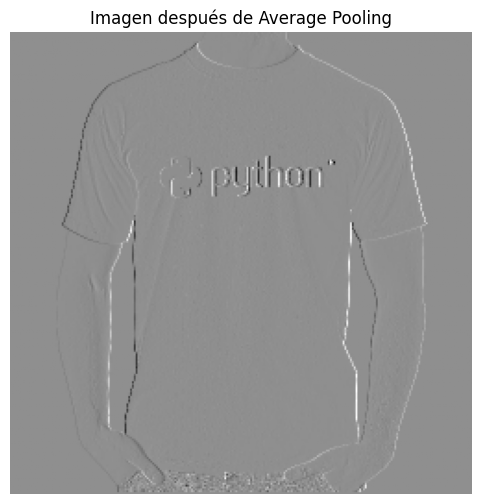

In [20]:
def average_pooling(image, pool_size=2):
    pooled_image = np.zeros((image.shape[0] // pool_size, image.shape[1] // pool_size))
    for i in range(0, image.shape[0] - pool_size, pool_size):
        for j in range(0, image.shape[1] - pool_size, pool_size):
            pooled_image[i // pool_size, j // pool_size] = np.mean(image[i:i+pool_size, j:j+pool_size])
    return pooled_image

# Aplicar Average Pooling
pooled_avg_image = average_pooling(convolved_stride, pool_size=2)

# Mostrar resultado
plt.figure(figsize=(6,6))
plt.imshow(pooled_avg_image, cmap='gray')
plt.title("Imagen después de Average Pooling")
plt.axis("off")
plt.show()